- **Import dependencies**

In [164]:
%reset -f
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm

- **Load the data**

In [165]:
# Import data
data = pd.read_parquet("/Users/euanbronsky/Downloads/data_final_final2.parquet")

# Locate the correct indices
data_select = data.loc[data.groupby(['quote_date', 'moneyness_group', 'maturity_group'])['distance'].idxmin()]

# Maintain only groups with length 24 and sort the dates
data_select = data_select.groupby('quote_date').filter(lambda x: len(x) == 24)

In [166]:
# First model
with open("/Users/euanbronsky/PyCharmMiscProject/first_results.pkl", "rb") as f:
    res_first = pickle.load(f)

# Basic model
with open("/Users/euanbronsky/PyCharmMiscProject/model1_results.pkl", 'rb') as f:
    res_basic = pickle.load(f)

# OU model
with open('/Users/euanbronsky/PyCharmMiscProject/model_ou_results.pkl', 'rb') as f:
    res_ou = pickle.load(f)

# Spline model
with open("/Users/euanbronsky/PyCharmMiscProject/spline_results.pkl", "rb") as f:
    res_spline = pickle.load(f)

- **Heatmap functions**

In [167]:
def make_residual_heatmap(
    data_heatmap,
    title='Average absolute residuals per group using full contract data',
    ax=None,
    show=True
):

    maturity_order = ["7-45", "45-90", "90-180", "180-360"]
    moneyness_order = ["DOTM_put", "OTM_put", "ATM_put", "ATM_call", "OTM_call", "DOTM_call"]

    data_heatmap = data_heatmap.copy()

    data_heatmap['maturity_group'] = pd.Categorical(
        data_heatmap['maturity_group'],
        categories=maturity_order,
        ordered=True
    )

    data_heatmap['moneyness_group'] = pd.Categorical(
        data_heatmap['moneyness_group'],
        categories=moneyness_order,
        ordered=True
    )

    heatmap_table = data_heatmap.pivot_table(
        values='abs_residual',
        index='maturity_group',
        columns='moneyness_group',
        aggfunc='mean',
        observed=False
    ).reindex(index=maturity_order, columns=moneyness_order)

    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 6))
    else:
        fig = ax.figure

    im = ax.imshow(heatmap_table, aspect='auto', cmap='Blues')

    for i in range(heatmap_table.shape[0]):
        for j in range(heatmap_table.shape[1]):
            ax.text(
                j, i, f"{heatmap_table.iloc[i, j]:.4f}",
                ha="center", va="center"
            )

    ax.invert_yaxis()
    ax.set_xticks(range(len(moneyness_order)))
    ax.set_xticklabels(moneyness_order, rotation=45, ha='right')
    ax.set_yticks(range(len(maturity_order)))
    ax.set_yticklabels(maturity_order)
    ax.set_xlabel('Moneyness group')
    ax.set_ylabel('Maturity group')
    ax.set_title(title)

    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label('Average absolute residual')

    if show:
        fig.tight_layout()
        plt.show()

    return heatmap_table

In [168]:
def make_state_model_residual_heatmap(
    data_source,
    model_dates,
    state_array,
    prepare_groups_function,
    title='Average absolute residuals per group using full contract data',
    ax=None,
    show=True
):

    data_heatmap = data_source[data_source['quote_date'].isin(model_dates)].copy()

    data_heatmap['quote_date'] = pd.Categorical(
        data_heatmap['quote_date'],
        categories=model_dates,
        ordered=True
    )

    data_heatmap = data_heatmap.sort_values('quote_date').copy()

    dates_data, _, Z_groups_data = prepare_groups_function(data_heatmap)

    log_iv_pred, iv_pred = predict_iv(
        Z_groups_data,
        state_array[:, :len(dates_data)]
    )

    data_heatmap['log_iv_pred'] = log_iv_pred
    data_heatmap['iv_pred'] = iv_pred
    data_heatmap['residual'] = data_heatmap['iv_fun'] - data_heatmap['iv_pred']
    data_heatmap['abs_residual'] = np.abs(data_heatmap['residual'])

    heatmap_table = make_residual_heatmap(
        data_heatmap,
        title=title,
        ax=ax,
        show=show
    )

    return data_heatmap, heatmap_table

- **Prepare groups**

In [169]:
# Group preparing function
def prepare_groups(x):

    # Extract dates and create empty lists
    dates = np.sort(x['quote_date'].unique())
    y_groups = []
    Z_groups = []

    # Loop over dates
    for date in dates:

        # Extract groups
        group = x[x['quote_date'] == date]

        # Extract relevant variables and append to lists
        y_groups.append(group['log_iv'].to_numpy(dtype=float))
        Z_groups.append(group[['constant', 'M', 'moneyness_squared', 'T', 'interaction']].to_numpy(dtype=float))

    # return the results
    return dates, y_groups, Z_groups

In [170]:
# Group preparing function
def prepare_groups_spline(x):

    # Sort the dates
    dates = np.sort(x['quote_date'].unique())

    # Create empty lists
    y_groups = []
    Z_groups = []

    # Loop over the dates
    for date in dates:

        # Extract the groups
        group = x[x['quote_date'] == date]

        # Append the y and Z groups to the lists
        y_groups.append(group['log_iv'].to_numpy(dtype=float))
        Z_groups.append(group[basis_cols].to_numpy(dtype=float))

    # Return the results
    return dates, y_groups, Z_groups

- **Predict IV**

In [171]:
# Prediction function
def predict_iv(Z_groups, at_pred):

    # Create empty list
    log_iv_pred = []

    # Loop over the number of groups
    for t in range(len(Z_groups)):

        # Extract the group
        Zt = Z_groups[t]

        # Extract the states
        beta_t = at_pred[:, t]

        # Compute predicted values
        log_iv_pred_t = Zt @ beta_t
        log_iv_pred.append(log_iv_pred_t)

    # Concatenate results and compute IV
    log_iv_pred = np.concatenate(log_iv_pred)
    iv_pred = np.exp(log_iv_pred)

    # Return the results
    return log_iv_pred, iv_pred

In [172]:
# Prediction function
def predict_var_iv(x, beta_start, omega, Phi):

    # Initialize beta and create empty lists
    beta_prev = beta_start
    log_iv_pred = []
    iv_pred = []

    # Loop over the groups
    for date, group in x.sort_values('quote_date').groupby('quote_date'):

        # One-step-ahead beta forecast
        beta_forecast = omega + Phi @ beta_prev

        # Regressor matrix
        X = group[['constant', 'M', 'moneyness_squared', 'T', 'interaction']]
        log_pred = X @ beta_forecast

        # Append results to lists
        log_iv_pred.append(pd.Series(log_pred, index=group.index, name='log_iv_pred'))
        iv_pred.append(pd.Series(np.exp(log_pred), index=group.index, name='iv_pred'))

        # Re-initialize beta
        beta_prev = beta_forecast

    # Return the results
    return pd.concat(iv_pred)

- **MSE and MAE**

In [173]:
# MSE and MAE function
def mse_mae(x, iv_pred):

    # Compute errors
    errors = x['iv_fun'] - iv_pred

    # Extract dates
    dates = pd.to_datetime(x['quote_date'])
    covid_mask = dates.between('2020-01-01', '2021-12-31')

    # Full testing sample metrics
    mse_full = np.mean(errors**2)
    mae_full = np.mean(np.abs(errors))

    # COVID metrics
    mse_covid = np.mean(errors[covid_mask]**2)
    mae_covid = np.mean(np.abs(errors[covid_mask]))

    # Non-COVID metrics
    mse_non_covid = np.mean(errors[~covid_mask]**2)
    mae_non_covid = np.mean(np.abs(errors[~covid_mask]))

    # Return the results
    return mse_full, mae_full, mse_covid, mae_covid, mse_non_covid, mae_non_covid

# **Basic model**

- **MSE MAE**

In [174]:
df_betas_train = res_first["df_betas"]
omega = res_first["omega"]
Phi = res_first["Phi"]
x_test = res_first["x_test"]

iv_pred_basic = predict_var_iv(
    x_test,
    df_betas_train.iloc[-1].values,
    omega,
    Phi
)

mse_full_basic, mae_full_basic, mse_covid_basic, mae_covid_basic, mse_non_covid_basic, mae_non_covid_basic = mse_mae(
    x_test,
    iv_pred_basic
)

print(f"Full sample metrics, MSE: {mse_full_basic:.5f}, MAE: {mae_full_basic:.5f}")
print(f"Non-COVID metrics, MSE: {mse_non_covid_basic:.5f}, MAE: {mae_non_covid_basic:.5f}")
print(f"COVID metrics: MSE: {mse_covid_basic:.5f}, MAE: {mae_covid_basic:.5f}")

Full sample metrics, MSE: 0.00537, MAE: 0.05046
Non-COVID metrics, MSE: 0.00291, MAE: 0.03998
COVID metrics: MSE: 0.00866, MAE: 0.06450


In [176]:
# Full test evaluation for first model
x_test_full_first = data[data["quote_date"].isin(x_test["quote_date"].unique())
].sort_values("quote_date").copy()

iv_pred_first_full = predict_var_iv(
    x_test_full_first,
    df_betas_train.iloc[-1].values,
    omega,
    Phi)

mse_full_first_full, mae_full_first_full, mse_covid_first_full, mae_covid_first_full, mse_non_covid_first_full, mae_non_covid_first_full = mse_mae(x_test_full_first,iv_pred_first_full)

print("Full test data")
print(f"Full sample metrics, MSE: {mse_full_first_full:.6f}, MAE: {mae_full_first_full:.6f}")
print(f"Non-COVID metrics, MSE: {mse_non_covid_first_full:.6f}, MAE: {mae_non_covid_first_full:.6f}")
print(f"COVID metrics, MSE: {mse_covid_first_full:.6f}, MAE: {mae_covid_first_full:.6f}")

Full test data
Full sample metrics, MSE: 0.008347, MAE: 0.057825
Non-COVID metrics, MSE: 0.005949, MAE: 0.050537
COVID metrics, MSE: 0.012389, MAE: 0.070109


- **Heatmap**

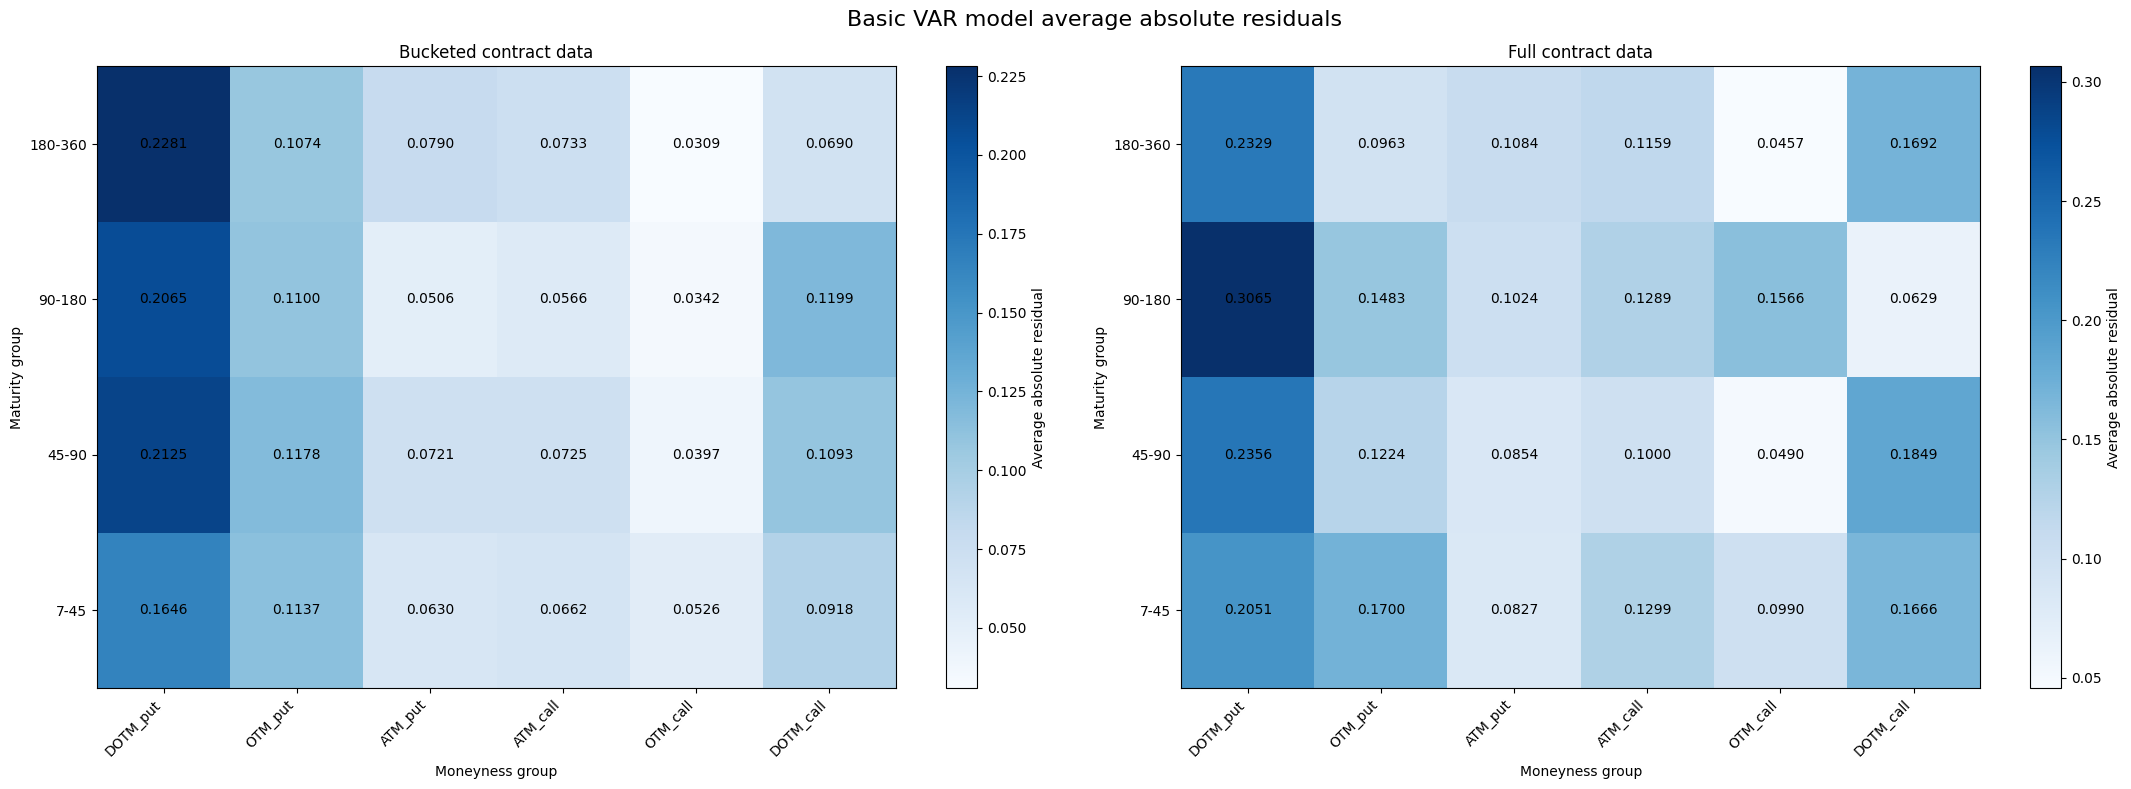

In [177]:
fig, axes = plt.subplots(1, 2, figsize=(22, 8))

# Bucketed heatmap
data_basic_bucketed = x_test.copy()
data_basic_bucketed["iv_pred"] = iv_pred_basic.to_numpy()
data_basic_bucketed["abs_residual"] = np.abs(
    data_basic_bucketed["iv_fun"] - data_basic_bucketed["iv_pred"]
)

heatmap_table_basic_bucketed = make_residual_heatmap(
    data_basic_bucketed,
    title="Bucketed contract data",
    ax=axes[0],
    show=False
)

# Full-data heatmap
data_basic_full = x_test_full_first.copy()
data_basic_full["iv_pred"] = iv_pred_first_full.to_numpy()
data_basic_full["abs_residual"] = np.abs(
    data_basic_full["iv_fun"] - data_basic_full["iv_pred"]
)

heatmap_table_basic_full = make_residual_heatmap(
    data_basic_full,
    title="Full contract data",
    ax=axes[1],
    show=False
)

fig.suptitle("Basic VAR model average absolute residuals", fontsize=16)
fig.tight_layout()
plt.show()

# **VAR model**

- **MSE and MAE**

In [178]:
# Unpack relevant variables
at_pred_var = res_basic["at_pred"]
x_train = res_basic["x_train"]
x_test = res_basic["x_test"]

# Prepare groups
dates_train_var, y_groups_train_var, Z_groups_train_var = prepare_groups(x_train)
n_train_dates_var = len(dates_train_var)

In [179]:
# Bucketed test evaluation
dates_test_var, y_groups_test_var, Z_groups_test_var = prepare_groups(x_test)

log_iv_pred_test_var, iv_pred_test_var = predict_iv(
    Z_groups_test_var,
    at_pred_var[:, n_train_dates_var:n_train_dates_var + len(dates_test_var)])

mse_full_var, mae_full_var, mse_covid_var, mae_covid_var, mse_non_covid_var, mae_non_covid_var = mse_mae(
    x_test,
    iv_pred_test_var)

print("Bucketed test data")
print(f"Full sample metrics, MSE: {mse_full_var:.6f}, MAE: {mae_full_var:.6f}")
print(f"Non-COVID metrics, MSE: {mse_non_covid_var:.6f}, MAE: {mae_non_covid_var:.6f}")
print(f"COVID metrics, MSE: {mse_covid_var:.6f}, MAE: {mae_covid_var:.6f}")

Bucketed test data
Full sample metrics, MSE: 0.000367, MAE: 0.011261
Non-COVID metrics, MSE: 0.000137, MAE: 0.008525
COVID metrics, MSE: 0.000675, MAE: 0.014926


In [180]:
# Full test evaluation
x_test_full_var = data[data["quote_date"].isin(dates_test_var)].copy()
x_test_full_var = x_test_full_var.sort_values("quote_date").copy()

dates_test_full_var, y_groups_test_full_var, Z_groups_test_full_var = prepare_groups(x_test_full_var)

log_iv_pred_test_full_var, iv_pred_test_full_var = predict_iv(
    Z_groups_test_full_var,
    at_pred_var[:, n_train_dates_var:n_train_dates_var + len(dates_test_full_var)])

mse_full_var_full, mae_full_var_full, mse_covid_var_full, mae_covid_var_full, mse_non_covid_var_full, mae_non_covid_var_full = mse_mae(
    x_test_full_var,
    iv_pred_test_full_var)

print("Full test data")
print(f"Full sample metrics, MSE: {mse_full_var_full:.6f}, MAE: {mae_full_var_full:.6f}")
print(f"Non-COVID metrics, MSE: {mse_non_covid_var_full:.6f}, MAE: {mae_non_covid_var_full:.6f}")
print(f"COVID metrics, MSE: {mse_covid_var_full:.6f}, MAE: {mae_covid_var_full:.6f}")

Full test data
Full sample metrics, MSE: 0.343553, MAE: 0.042515
Non-COVID metrics, MSE: 0.539228, MAE: 0.040362
COVID metrics, MSE: 0.013721, MAE: 0.046144


- **Heatmaps**

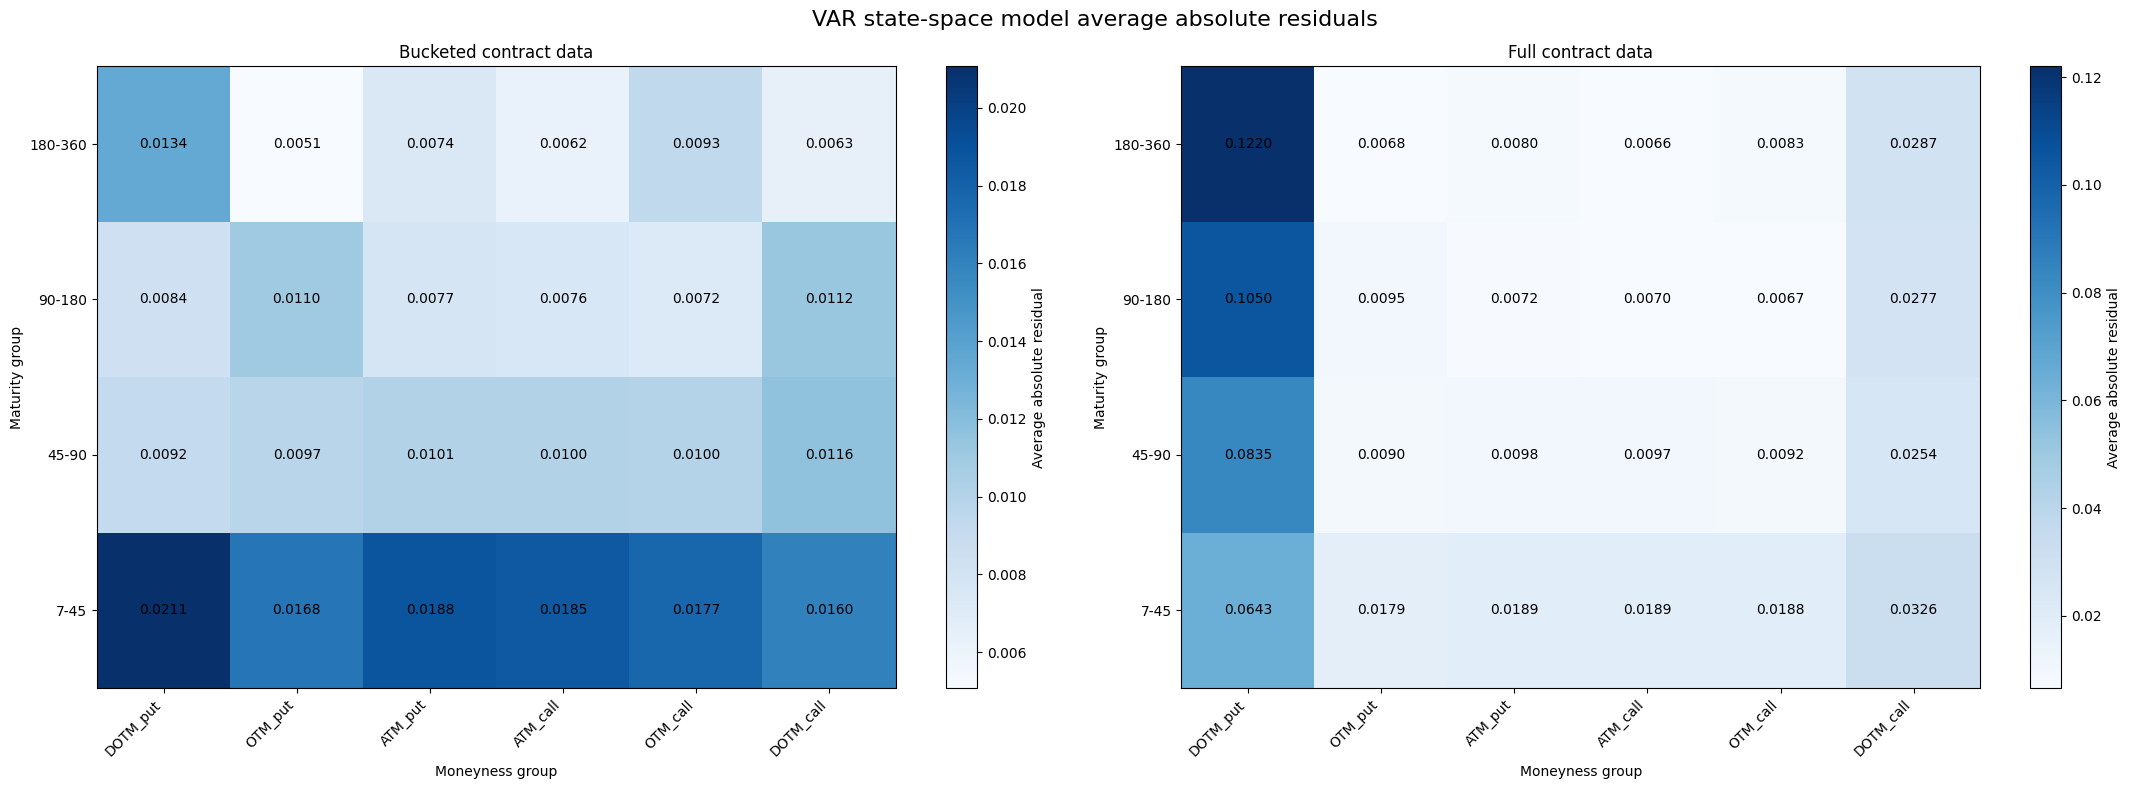

In [181]:
fig, axes = plt.subplots(1, 2, figsize=(22, 8))

data_heatmap_var, heatmap_table_var = make_state_model_residual_heatmap(
    x_test,
    dates_test_var,
    at_pred_var[:, n_train_dates_var:n_train_dates_var + len(dates_test_var)],
    prepare_groups,
    title="Bucketed contract data",
    ax=axes[0],
    show=False
)

data_heatmap_var_full, heatmap_table_var_full = make_state_model_residual_heatmap(
    x_test_full_var,
    dates_test_full_var,
    at_pred_var[:, n_train_dates_var:n_train_dates_var + len(dates_test_full_var)],
    prepare_groups,
    title="Full contract data",
    ax=axes[1],
    show=False
)

fig.suptitle(
    "VAR state-space model average absolute residuals",
    fontsize=16)

fig.tight_layout()
plt.show()

In [77]:
data_full_pred = data[data['quote_date'].isin(dates)].copy()

dates_full, _, Z_groups_full = prepare_groups(data_full_pred)

_, iv_pred_full = predict_iv(
    Z_groups_full,
    at_pred
)

data_full_pred['iv_pred'] = iv_pred_full
data_full_pred['resid'] = data_full_pred['iv_fun'] - data_full_pred['iv_pred']
blues_no_white = LinearSegmentedColormap.from_list(
    'blues_no_white',
    cm.Blues_r(np.linspace(0.02, 0.82, 256)))

date_2016 = data_full_pred.loc[
    (data_full_pred['quote_date'] == '2016-03-21') &
    (data_full_pred['option_type'] == 'put')]

date_2020 = data_full_pred.loc[
    (data_full_pred['quote_date'] == '2020-03-04') &
    (data_full_pred['option_type'] == 'put')]

date_2023 = data_full_pred.loc[
    (data_full_pred['quote_date'] == '2023-08-07') &
    (data_full_pred['option_type'] == 'put')]

fig, axes = plt.subplots(1, 3, figsize=(18, 16), subplot_kw={'projection': '3d'})
#fig.subplots_adjust(wspace=1)

surf1 = axes[0].plot_trisurf(
    date_2016['delta_fun'],
    date_2016['T'],
    date_2016['resid'],
    cmap=blues_no_white,
    edgecolor='none',
    antialiased=True,
    alpha=0.9
)

surf2 = axes[1].plot_trisurf(
    date_2020['delta_fun'],
    date_2020['T'],
    date_2020['resid'],
    cmap=blues_no_white,
    edgecolor='none',
    antialiased=True,
    alpha=0.9
)

surf3 = axes[2].plot_trisurf(
    date_2023['delta_fun'],
    date_2023['T'],
    date_2023['resid'],
    cmap=blues_no_white,
    edgecolor='none',
    antialiased=True,
    alpha=0.9
)

zlabels = ['Residual', 'Residual', 'Residual']

for ax, zlabel in zip(axes, zlabels):
    ax.set_xlabel('Delta', labelpad=10)
    ax.set_ylabel('Maturity', labelpad=10)
    ax.set_zlabel(zlabel, labelpad=10)
    ax.invert_xaxis()
    ax.view_init(elev=20, azim=-25)
    ax.xaxis._axinfo["grid"]["color"] = (0.5, 0.5, 0.5, 0.45)
    ax.yaxis._axinfo["grid"]["color"] = (0.5, 0.5, 0.5, 0.45)
    ax.zaxis._axinfo["grid"]["color"] = (0.5, 0.5, 0.5, 0.45)

fig.colorbar(surf1, ax=axes[0], shrink=0.08, aspect=7, pad=0.14)
fig.colorbar(surf2, ax=axes[1], shrink=0.08, aspect=7, pad=0.14)
fig.colorbar(surf3, ax=axes[2], shrink=0.08, aspect=7, pad=0.14)

plt.tight_layout()
plt.savefig("/Users/euanbronsky/Downloads/three.IV.Plot.png", bbox_inches='tight')
plt.show()

NameError: name 'dates' is not defined

In [ ]:
import pyfixest as pf
from scipy.stats import norm

data_full_pred["abs_resid"] = data_full_pred["resid"].abs()

data_full_pred["deep_put"] = (
    data_full_pred["moneyness_group"] == "DOTM_put"
).astype(int)

data_full_pred["deep_call"] = (
    data_full_pred["moneyness_group"] == "DOTM_call"
).astype(int)

test_data = data_full_pred[
    data_full_pred["moneyness_group"].isin([
        "ATM_put", "ATM_call",
        "OTM_put", "OTM_call",
        "DOTM_put", "DOTM_call"
    ])
].copy()

reg = pf.feols(
    "abs_resid ~ deep_put + deep_call | quote_date + maturity_group",
    data=test_data,
    vcov={"CRV1": "quote_date"}
)

print(reg.summary())

gamma_put = reg.coef()["deep_put"]
se_put = reg.se()["deep_put"]
t_put = gamma_put / se_put
p_put = 1 - norm.cdf(t_put)

gamma_call = reg.coef()["deep_call"]
se_call = reg.se()["deep_call"]
t_call = gamma_call / se_call
p_call = 1 - norm.cdf(t_call)

print("gamma_put:", gamma_put)
print("t_put:", t_put)
print("one-sided p_put:", p_put)

print("gamma_call:", gamma_call)
print("t_call:", t_call)
print("one-sided p_call:", p_call)

# **OU model**

In [182]:
at_pred_ou = res_ou["at_pred"]

dates_train_ou, y_groups_train_ou, Z_groups_train_ou = prepare_groups(x_train)
n_train_dates_ou = len(dates_train_ou)

In [183]:
# Bucketed test evaluation
dates_test_ou, y_groups_test_ou, Z_groups_test_ou = prepare_groups(x_test)

log_iv_pred_test_ou, iv_pred_test_ou = predict_iv(
    Z_groups_test_ou,
    at_pred_ou[:, n_train_dates_ou:n_train_dates_ou + len(dates_test_ou)]
)

mse_full_ou, mae_full_ou, mse_covid_ou, mae_covid_ou, mse_non_covid_ou, mae_non_covid_ou = mse_mae(
    x_test,
    iv_pred_test_ou
)

print("Bucketed test data")
print(f"Full sample metrics, MSE: {mse_full_ou:.6f}, MAE: {mae_full_ou:.6f}")
print(f"Non-COVID metrics, MSE: {mse_non_covid_ou:.6f}, MAE: {mae_non_covid_ou:.6f}")
print(f"COVID metrics, MSE: {mse_covid_ou:.6f}, MAE: {mae_covid_ou:.6f}")


Bucketed test data
Full sample metrics, MSE: 0.000388, MAE: 0.011450
Non-COVID metrics, MSE: 0.000141, MAE: 0.008639
COVID metrics, MSE: 0.000719, MAE: 0.015215


In [184]:
# Full test evaluation
x_test_full_ou = data[data["quote_date"].isin(dates_test_ou)].copy()
x_test_full_ou = x_test_full_ou.sort_values("quote_date").copy()

dates_test_full_ou, y_groups_test_full_ou, Z_groups_test_full_ou = prepare_groups(x_test_full_ou)

log_iv_pred_test_full_ou, iv_pred_test_full_ou = predict_iv(
    Z_groups_test_full_ou,
    at_pred_ou[:, n_train_dates_ou:n_train_dates_ou + len(dates_test_full_ou)]
)

mse_full_ou_full, mae_full_ou_full, mse_covid_ou_full, mae_covid_ou_full, mse_non_covid_ou_full, mae_non_covid_ou_full = mse_mae(
    x_test_full_ou,
    iv_pred_test_full_ou
)

print("Full test data")
print(f"Full sample metrics, MSE: {mse_full_ou_full:.6f}, MAE: {mae_full_ou_full:.6f}")
print(f"Non-COVID metrics, MSE: {mse_non_covid_ou_full:.6f}, MAE: {mae_non_covid_ou_full:.6f}")
print(f"COVID metrics, MSE: {mse_covid_ou_full:.6f}, MAE: {mae_covid_ou_full:.6f}")

Full test data
Full sample metrics, MSE: 0.009393, MAE: 0.037014
Non-COVID metrics, MSE: 0.006213, MAE: 0.028897
COVID metrics, MSE: 0.014754, MAE: 0.050696


- **Heatmap**

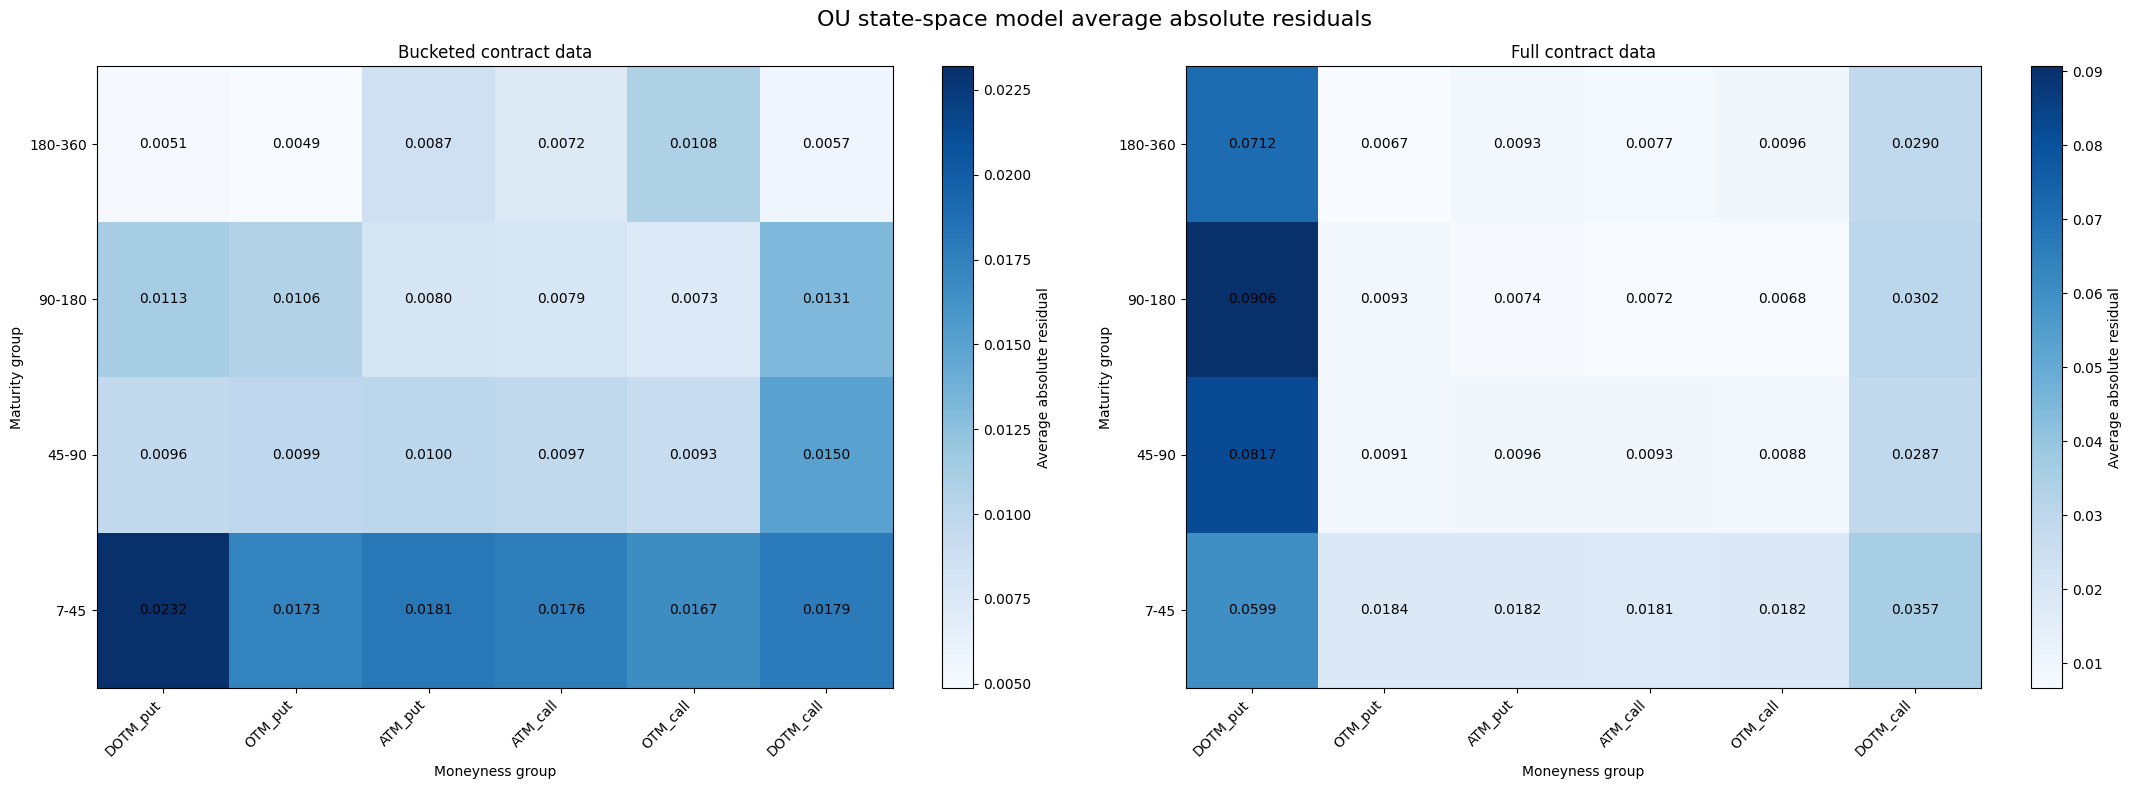

In [185]:
fig, axes = plt.subplots(1, 2, figsize=(22, 8))

data_heatmap_ou, heatmap_table_ou = make_state_model_residual_heatmap(
    x_test,
    dates_test_ou,
    at_pred_ou[:, n_train_dates_ou:n_train_dates_ou + len(dates_test_ou)],
    prepare_groups,
    title="Bucketed contract data",
    ax=axes[0],
    show=False
)

data_heatmap_ou_full, heatmap_table_ou_full = make_state_model_residual_heatmap(
    x_test_full_ou,
    dates_test_full_ou,
    at_pred_ou[:, n_train_dates_ou:n_train_dates_ou + len(dates_test_full_ou)],
    prepare_groups,
    title="Full contract data",
    ax=axes[1],
    show=False
)

fig.suptitle(
    "OU state-space model average absolute residuals",
    fontsize=16
)

fig.tight_layout()
plt.show()

# **Spline model**

In [192]:
at_pred_spline = res_spline["at_pred"]

x_train_spline = res_spline["x_train_spline"]
x_test_spline = res_spline["x_test_spline"]

basis_cols = res_spline["basis_cols"]

dates_train_spline, y_groups_train_spline, Z_groups_train_spline = prepare_groups_spline(x_train_spline)
n_train_dates_spline = len(dates_train_spline)
dates_test_spline, y_groups_test_spline, Z_groups_test_spline = prepare_groups_spline(x_test_spline)

log_iv_pred_train_spline, iv_pred_train_spline = predict_iv(
    Z_groups_train_spline,
    at_pred_spline[:, :n_train_dates_spline]
)

log_iv_pred_test_spline, iv_pred_test_spline = predict_iv(
    Z_groups_test_spline,
    at_pred_spline[:, n_train_dates_spline:n_train_dates_spline + len(dates_test_spline)])

In [187]:
mse_full_spline, mae_full_spline, mse_covid_spline, mae_covid_spline, mse_non_covid_spline, mae_non_covid_spline = mse_mae(
    x_test_spline,
    iv_pred_test_spline)
print(f"Full sample metrics, MSE: {mse_full_spline:.6f}, MAE: {mae_full_spline:.6f}")
print(f"Non-COVID metrics, MSE: {mse_non_covid_spline:.6f}, MAE: {mae_non_covid_spline:.6f}")
print(f"COVID metrics, MSE: {mse_covid_spline:.6f}, MAE: {mae_covid_spline:.6f}")

Full sample metrics, MSE: 0.000187, MAE: 0.008405
Non-COVID metrics, MSE: 0.000103, MAE: 0.006998
COVID metrics, MSE: 0.000302, MAE: 0.010340


In [188]:
data_spline_full = res_spline["data_spline_full"]

x_test_full_spline = data_spline_full[data_spline_full["quote_date"].isin(dates_test_spline)].copy()
x_test_full_spline = x_test_full_spline.sort_values("quote_date").copy()

dates_test_full_spline, y_groups_test_full_spline, Z_groups_test_full_spline = prepare_groups_spline(x_test_full_spline)

log_iv_pred_test_full_spline, iv_pred_test_full_spline = predict_iv(
    Z_groups_test_full_spline,
    at_pred_spline[:, n_train_dates_spline:n_train_dates_spline + len(dates_test_full_spline)]
)

mse_full_spline_full, mae_full_spline_full, mse_covid_spline_full, mae_covid_spline_full, mse_non_covid_spline_full, mae_non_covid_spline_full = mse_mae(
    x_test_full_spline,
    iv_pred_test_full_spline
)

print(f"Full sample metrics, MSE: {mse_full_spline_full:.6f}, MAE: {mae_full_spline_full:.6f}")
print(f"Non-COVID metrics, MSE: {mse_non_covid_spline_full:.6f}, MAE: {mae_non_covid_spline_full:.6f}")
print(f"COVID metrics, MSE: {mse_covid_spline_full:.6f}, MAE: {mae_covid_spline_full:.6f}")

Full sample metrics, MSE: 0.007176, MAE: 0.034817
Non-COVID metrics, MSE: 0.005843, MAE: 0.030441
COVID metrics, MSE: 0.009602, MAE: 0.042779


- **Heatmaps**

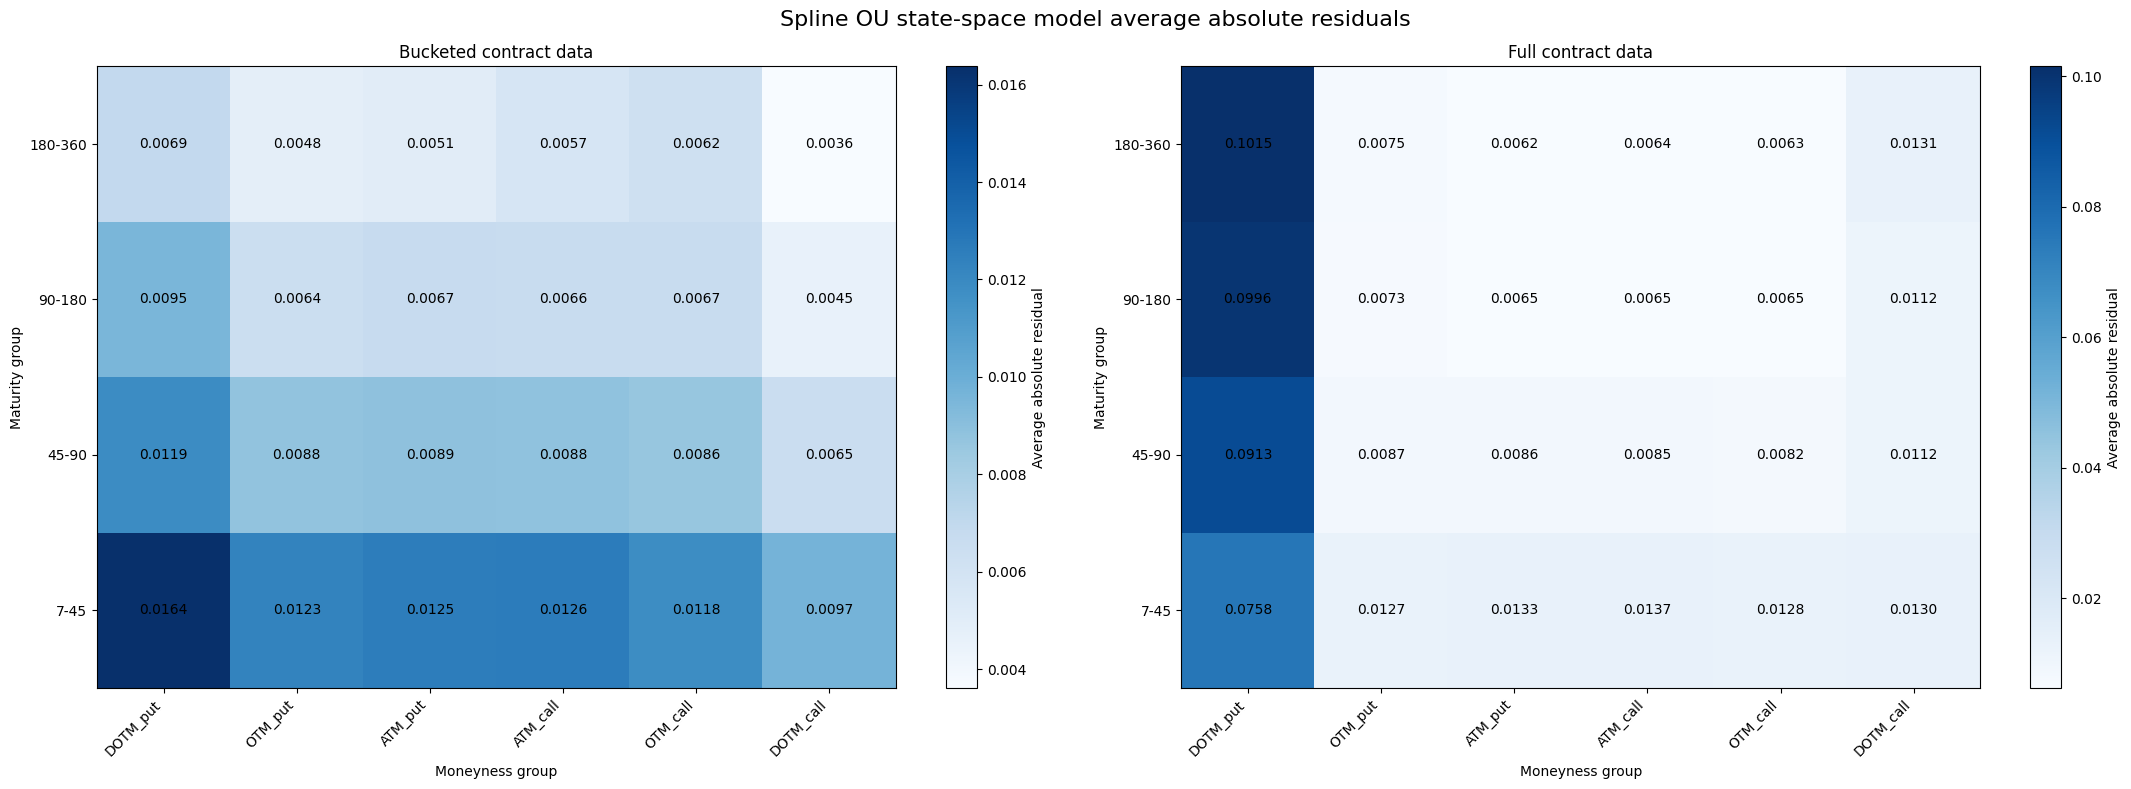

In [191]:
fig, axes = plt.subplots(1, 2, figsize=(22, 8))

data_heatmap_spline_bucketed, heatmap_table_spline_bucketed = make_state_model_residual_heatmap(
    x_test_spline,
    dates_test_spline,
    at_pred_spline[:, n_train_dates_spline:n_train_dates_spline + len(dates_test_spline)],
    prepare_groups_spline,
    title="Bucketed contract data",
    ax=axes[0],
    show=False
)

data_heatmap_spline_full, heatmap_table_spline_full = make_state_model_residual_heatmap(
    x_test_full_spline,
    dates_test_full_spline,
    at_pred_spline[:, n_train_dates_spline:n_train_dates_spline + len(dates_test_full_spline)],
    prepare_groups_spline,
    title="Full contract data",
    ax=axes[1],
    show=False
)

fig.suptitle(
    "Spline OU state-space model average absolute residuals",
    fontsize=16
)

fig.tight_layout()
plt.show()

- **Diebold-Mariano test**

In [ ]:
# Diebold-Mariano test function
def dm_test(errors_model, errors_benchmark, power=2, lag=5):

    # Convert to NumPy arrays
    e1 = np.asarray(errors_model)
    e0 = np.asarray(errors_benchmark)

    # Compute loss differential
    loss_diff = np.abs(e1)**power - np.abs(e0)**power

    # Length of loss differential
    T = len(loss_diff)

    # Mean of loss differential and demean it
    d_bar = np.mean(loss_diff)
    u = loss_diff - d_bar

    # Compute long run variance
    lrv = np.mean(u * u)

    # HAC/Newey-West for serial correlation
    for j in range(1, lag + 1):
        gamma = np.mean(u[j:] * u[:-j])
        lrv += 2 * (1 - j / (lag + 1)) * gamma

    # Standard errors
    se = np.sqrt(lrv / T)

    # Compute the test statistic and p-value
    dm_stat = d_bar / se
    p_value = 2 * (1 - norm.cdf(np.abs(dm_stat)))

    # Return the results
    return dm_stat, p_value

In [193]:
import pickle

with open("iv_pred_train_spline.pkl", "wb") as f:
    pickle.dump(iv_pred_train_spline, f)